# Confronto semplice tra Batch, Mini-batch e Stochastic Gradient Descent

In questo notebook confrontiamo **3 varianti del gradient descent** su una funzione costo con **2 variabili** ($w_1, w_2$).
Obiettivi:
- capire la differenza pratica tra Batch GD, Mini-batch GD e SGD
- osservare come cambia la discesa della cost function
- visualizzare il percorso dei parametri su un contour plot 2D

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.style.use("seaborn-v0_8")

## 1) Dataset sintetico e funzione costo

Usiamo una regressione lineare senza bias:

$$
\hat{y} = w_1 x_1 + w_2 x_2 = (x_1, \  x_2)\cdot (w_1, \ w_2)^T
$$

La cost function (MSE) dipende quindi da **due soli parametri**:

$$
C(w_1, w_2) = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2,
$$

dove $N=1$ per SGD, $N$ coincide con $N_{train}$ (numero di dati nel training set) per vanilla gradient descent, e $1<N<N_{train}$ per mini-batch.

Poi visualizzeremo il processo di training nel piano bidimensionale $(w_1, w_2)$.

In [2]:
# Generazione dati
n_samples = 500
X = np.random.randn(n_samples, 2)
true_w = np.array([3.0, -2.0])
noise = np.random.randn(n_samples)
y = X @ true_w + noise

# Funzioni utili
def predict(X, w):
    return X @ w

def cost_mse(X, y, w):
    err = predict(X, w) - y
    return np.mean(err ** 2)

def gradient_mse(X_batch, y_batch, w):
    err = X_batch @ w - y_batch
    return (2.0 / len(X_batch)) * (X_batch.T @ err)

print("Forma X:", X.shape)
print("Pesi reali:", true_w)

Forma X: (500, 2)
Pesi reali: [ 3. -2.]


## 2) Implementazione dei 3 tipi di Gradient Descent

- **Batch GD**: usa tutti i dati a ogni aggiornamento
- **Mini-batch GD**: usa piccoli gruppi di dati
- **Stochastic GD (SGD)**: usa un solo campione per volta

Per confrontarli in modo corretto, registriamo:
- traiettoria dei pesi $(w_1, w_2)$
- valore della cost function a ogni epoca (calcolato su tutto il dataset)

# Esercizio: 

1) Scrivere una funzione python (con anche altre funzioni ausiliare se necessario) che effettua il training del modello definito prima. La funzione calcola il gradiente e aggiorna i parametri tramite la regola di update ordinaria. Definisci tutti gli altri "iperparametri" che servono per questo scopo. La funzione deve accettare un parametro di input "mode" che gestisce i 3 tipi di gradient descent visti prima.

2) Mostrare il grafico del percorso seguito dai parametri aggiornati, epoca per epoca, in un piano 2d dei parametri $(w_1, w_2)$. Il grafico mostrerà 3 line plot, uno per ogni tipo di gradient descent.

3) Mostrare il grafico della Cost function come funzione dell'epoca di training. Il grafico mostrerà 3 line plot, uno per ogni tipo di gradient descent.

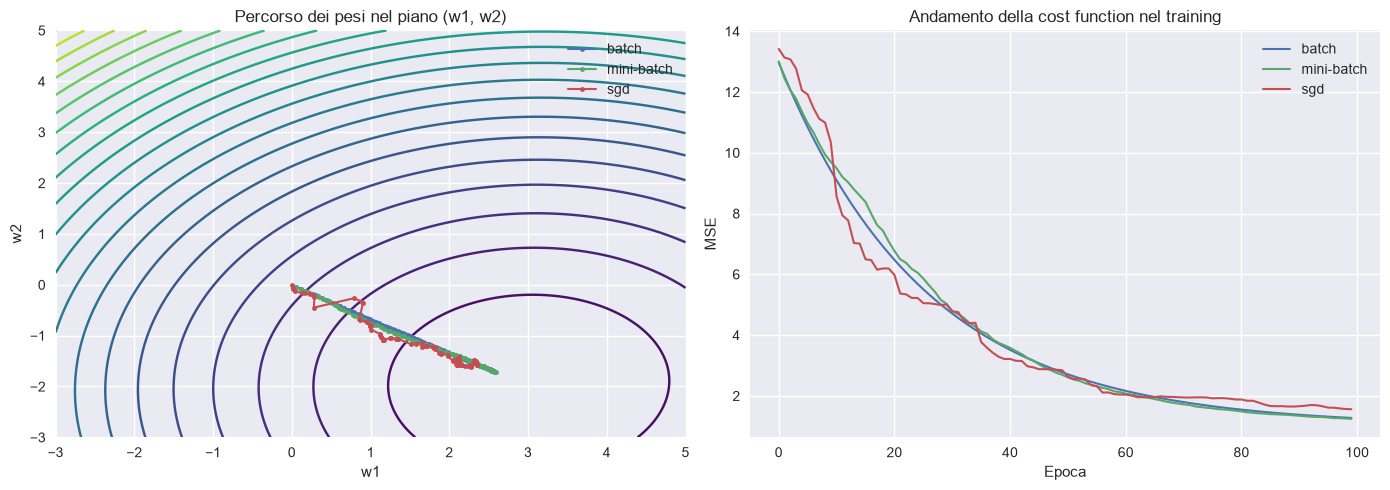

In [3]:
# Esercizio completato: training con i 3 tipi di gradient descent

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


def predict(X, w):
    return X @ w


def cost_mse(X, y, w):
    err = predict(X, w) - y
    return np.mean(err ** 2)


def gradient_mse(X_batch, y_batch, w):
    err = X_batch @ w - y_batch
    return (2.0 / len(X_batch)) * (X_batch.T @ err)


def train_gd(X, y, mode="batch", learning_rate=0.01, epochs=100, batch_size=32, init_w=None):
    n_samples = len(X)
    w = np.zeros(X.shape[1]) if init_w is None else init_w.copy()
    traj = []
    costs = []

    for epoch in range(epochs):
        if mode == "batch":
            batch_idx = np.arange(n_samples)
        elif mode == "mini-batch":
            perm = np.random.permutation(n_samples)
            batch_idx = perm[:batch_size]
        elif mode == "sgd":
            batch_idx = np.array([np.random.randint(0, n_samples)])
        else:
            raise ValueError("mode deve essere 'batch', 'mini-batch' o 'sgd'")

        X_batch = X[batch_idx]
        y_batch = y[batch_idx]
        grad = gradient_mse(X_batch, y_batch, w)
        w = w - learning_rate * grad

        traj.append(w.copy())
        costs.append(cost_mse(X, y, w))

    return np.array(traj), np.array(costs)


modes = ["batch", "mini-batch", "sgd"]
results = {}
for mode in modes:
    traj, costs = train_gd(X, y, mode=mode, learning_rate=0.01, epochs=100, batch_size=32)
    results[mode] = (traj, costs)


# Contour plot del costo nel piano (w1, w2)
xx = np.linspace(-3, 5, 200)
yy = np.linspace(-3, 5, 200)
W1, W2 = np.meshgrid(xx, yy)
Z = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_grid = np.array([W1[i, j], W2[i, j]])
        Z[i, j] = cost_mse(X, y, w_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cs = axes[0].contour(W1, W2, Z, levels=20, cmap="viridis")
axes[0].set_title("Percorso dei pesi nel piano (w1, w2)")
axes[0].set_xlabel("w1")
axes[0].set_ylabel("w2")
axes[0].grid(True)

for mode in modes:
    traj, _ = results[mode]
    axes[0].plot(traj[:, 0], traj[:, 1], marker=".", linewidth=1.5, label=mode)
axes[0].legend()

for mode in modes:
    _, costs = results[mode]
    axes[1].plot(costs, label=mode, linewidth=1.5)
axes[1].set_title("Andamento della cost function nel training")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


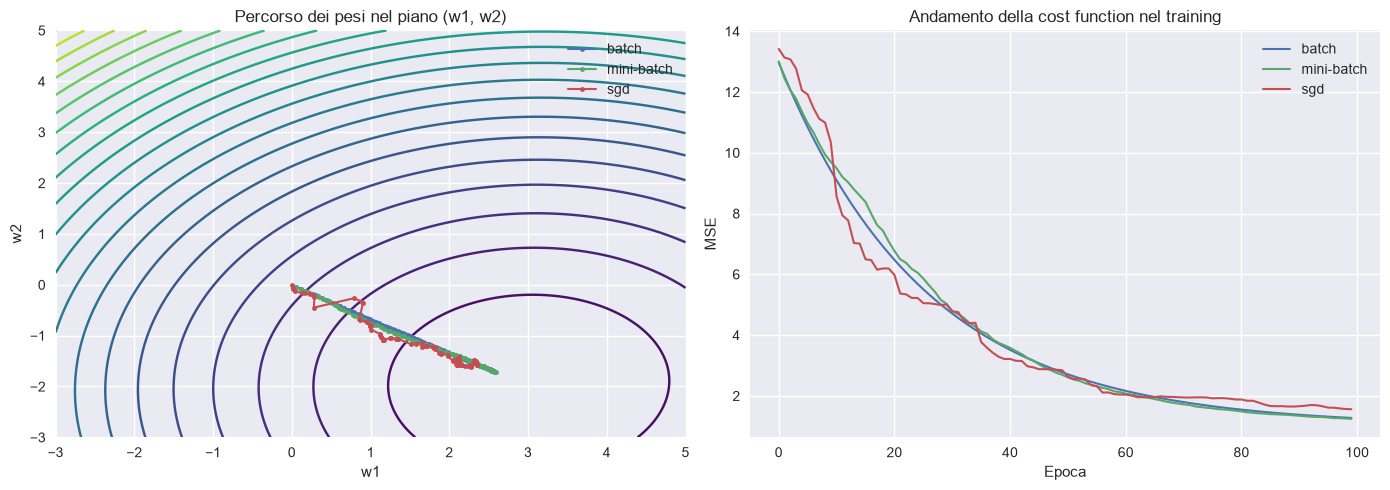

In [4]:
# Versione con commenti del codice per capire ogni passaggio

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1) Funzione che calcola la previsione del modello
#    w è il vettore dei pesi, X è la matrice dei dati
#    la previsione è: y_hat = X @ w

def predict(X, w):
    return X @ w

# 2) Funzione che calcola il costo MSE
#    confronta la previsione con il valore reale y

def cost_mse(X, y, w):
    err = predict(X, w) - y
    return np.mean(err ** 2)

# 3) Funzione che calcola il gradiente della MSE
#    il gradiente indica la direzione in cui il costo diminuisce

def gradient_mse(X_batch, y_batch, w):
    err = X_batch @ w - y_batch
    return (2.0 / len(X_batch)) * (X_batch.T @ err)

# 4) Funzione generale di training
#    mode può essere: 'batch', 'mini-batch' o 'sgd'
#    questa funzione esegue il training e salva la traiettoria dei pesi e il costo

def train_gd(X, y, mode="batch", learning_rate=0.01, epochs=100, batch_size=32, init_w=None):
    n_samples = len(X)

    # inizializzo i pesi a zero se non vengono passati
    w = np.zeros(X.shape[1]) if init_w is None else init_w.copy()

    # liste per salvare i risultati ad ogni epoca
    traj = []
    costs = []

    for epoch in range(epochs):
        # scegli il sottoinsieme di dati in base al metodo
        if mode == "batch":
            batch_idx = np.arange(n_samples)      # usa tutti i dati
        elif mode == "mini-batch":
            perm = np.random.permutation(n_samples)
            batch_idx = perm[:batch_size]        # usa un piccolo gruppo di dati
        elif mode == "sgd":
            batch_idx = np.array([np.random.randint(0, n_samples)])  # usa un singolo dato
        else:
            raise ValueError("mode deve essere 'batch', 'mini-batch' o 'sgd'")

        # estraggo il batch e il target corrispondente
        X_batch = X[batch_idx]
        y_batch = y[batch_idx]

        # calcolo il gradiente sul batch scelto
        grad = gradient_mse(X_batch, y_batch, w)

        # aggiorno i pesi con la regola del gradient descent
        w = w - learning_rate * grad

        # salvo il nuovo peso e il costo corrispondente
        traj.append(w.copy())
        costs.append(cost_mse(X, y, w))

    return np.array(traj), np.array(costs)

# 5) Eseguo il training per i 3 metodi
modes = ["batch", "mini-batch", "sgd"]
results = {}

for mode in modes:
    traj, costs = train_gd(X, y, mode=mode, learning_rate=0.01, epochs=100, batch_size=32)
    results[mode] = (traj, costs)

# 6) Creo il contour plot del costo nel piano (w1, w2)
xx = np.linspace(-3, 5, 200)
yy = np.linspace(-3, 5, 200)
W1, W2 = np.meshgrid(xx, yy)
Z = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_grid = np.array([W1[i, j], W2[i, j]])
        Z[i, j] = cost_mse(X, y, w_grid)

# 7) Disegno il grafico del percorso dei pesi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].contour(W1, W2, Z, levels=20, cmap="viridis")
axes[0].set_title("Percorso dei pesi nel piano (w1, w2)")
axes[0].set_xlabel("w1")
axes[0].set_ylabel("w2")
axes[0].grid(True)

for mode in modes:
    traj, _ = results[mode]
    axes[0].plot(traj[:, 0], traj[:, 1], marker=".", linewidth=1.5, label=mode)
axes[0].legend()

# 8) Disegno il grafico del costo nel tempo
for mode in modes:
    _, costs = results[mode]
    axes[1].plot(costs, label=mode, linewidth=1.5)
axes[1].set_title("Andamento della cost function nel training")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()